**Introduction to Machine Learning**

In this project, we will create an end-to-end machine learning (ML) project to become familiar with different stages in ML pipeline.

**Reference:** The example in this notebook is based on chapter 2 of Aurelien Geron's book available at MRU library.

This project requires Python 3.7 or above.
It also requires Scikit-Learn ≥ 1.0.1:

In [1]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split

# Problem Statement

Your task is to use California census data to build a model of housing prices in the state. This data includes metrics such as the **population**, **median** **income**, and **median housing price** for each block group, i.e., districts, in California. Your model should learn from this data and be able to **predict the median housing price** in any district, given all the other metrics.

## Frame the Problem

Building a model is probably not the end goal. Ask questions to undrestand the end goal!

**How does the company expect to use and benefit from this model?**

Answer: Your model’s output (a prediction of a district’s median housing price) will be fed to another Machine Learning system, along with many other signals. This downstream system will determine whether it is worth investing in a given area or not.


**What are the current solutions (if any)?** This question will often give you a reference for performance, as well as insights on how to solve the problem.

Answer: The district housing prices are currently estimated manually by experts, a team gathers up-to-date information about a district, and when they cannot get the median housing price, they estimate it using complex rules.
This is costly and time-consuming, and their estimates are not great; in cases where they manage to find out the actual median housing price, they often realize that their estimates were off by more than 20%.

<font color='red'>Question</font>

*   Is this supervised, unsupervised learning?
*   Is it a clustering task, classification task, a regression task or none?



<font color='red'>Question</font>
What are the other common performance measures for regression problems?



## Performance Measures  - Regression

*    R Square/Adjusted R Square measures how much variability in dependent variable can be explained by the model. R Square is a good measure to determine how well the model fits the dependent variables. However, it does not take into consideration of overfitting problem. Values range from 0 to 1, and the closer the values are to 1, the better the model is.

*    Mean Square Error(MSE) is calculated by the sum of square of prediction error which is real output minus predicted output and then divide by the number of data points. It gives you an absolute number on how much your predicted results deviate from the actual number.

*    Root Mean Square Error(RMSE) is the square root of MSE. *RMSE is preferred*.

*    Mean Absolute Error(MAE) is similar to Mean Square Error(MSE). However, instead of the sum of square of error in MSE, MAE is taking the sum of the absolute value of error.


## Steps to follow

1.   Get data
2.   Explore data
3.   Prepare data
4.   Select and train model
5.   Tune your model


# Get the Data

## Download the Data

In [2]:
housing = pd.read_csv("Cal_Housing.csv")

## Take a Quick Look at the Data Structure

In [3]:
housing.head()

,Unnamed: 0,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [4]:
housing.describe()

,Unnamed: 0,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,10319.500000,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,5958.399114,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,0.000000,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,5159.750000,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,10319.500000,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,15479.250000,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,20639.000000,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          20640 non-null  int64  
 1   longitude           20640 non-null  float64
 2   latitude            20640 non-null  float64
 3   housing_median_age  20640 non-null  int64  
 4   total_rooms         20640 non-null  int64  
 5   total_bedrooms      20433 non-null  float64
 6   population          20640 non-null  int64  
 7   households          20640 non-null  int64  
 8   median_income       20640 non-null  float64
 9   median_house_value  20640 non-null  int64  
 10  ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(6), object(1)
memory usage: 1.7+ MB


In [6]:
housing["ocean_proximity"].value_counts()

<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

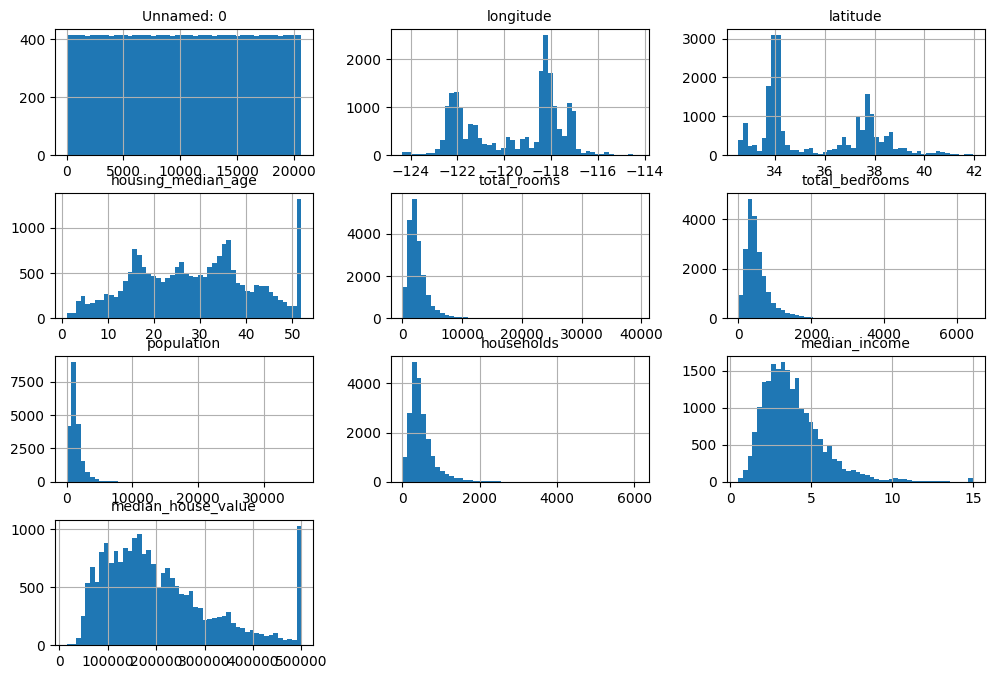

In [7]:
plt.rc('font', size=10)
plt.rc('axes', labelsize=10, titlesize=10)
plt.rc('legend', fontsize=10)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

housing.hist(bins=50, figsize=(12, 8))
plt.show()

# Create a Test Set

<font color='red'>Question</font>

*   What is test set and why should you set a side a test set?
*   Can we select test set later in the project?
*   What is data snooping bias?



In [8]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

### Stratified Strategy


*   **Simple random samples** and stratified random samples are both common methods for obtaining a sample. A simple random sample is used to represent the entire data population and randomly selects individuals from the population without any other consideration.
*   A **stratified random sample**, on the other hand, first divides the population into smaller groups, or strata, based on shared characteristics. Therefore, a stratified sampling strategy will ensure that members from each subgroup are included in the data analysis.


<font color="red">Question</font>
What are the possible issues with random sampling of test/train data?


It's much shorter to get a single stratified split:

In [9]:
strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

In [10]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# Discover and Visualize the Data to Gain Insights

In [11]:
housing = strat_train_set.copy()

## Visualizing Geographical Data

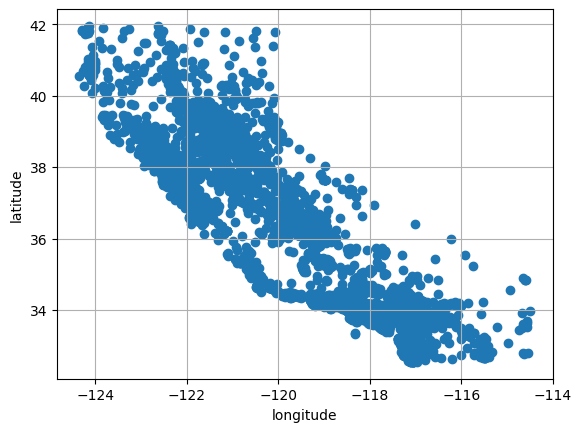

In [12]:
plt.scatter(x=housing["longitude"], y=housing["latitude"])
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.grid(True)
plt.show()

Alternative: You can plot the same graph with applying plot function on your data frame.

In [13]:
# housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
# plt.show()

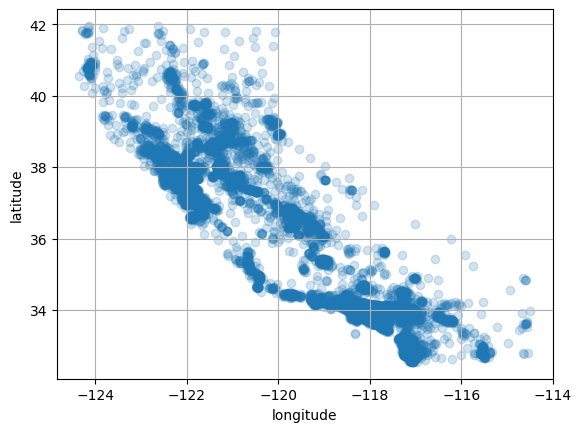

In [14]:
plot1 = plt.scatter(x=housing["longitude"], y=housing["latitude"])
plot1.set_alpha(0.2)
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.grid(True)
plt.show()

Alternative Approach:

In [15]:
# housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
# plt.show()

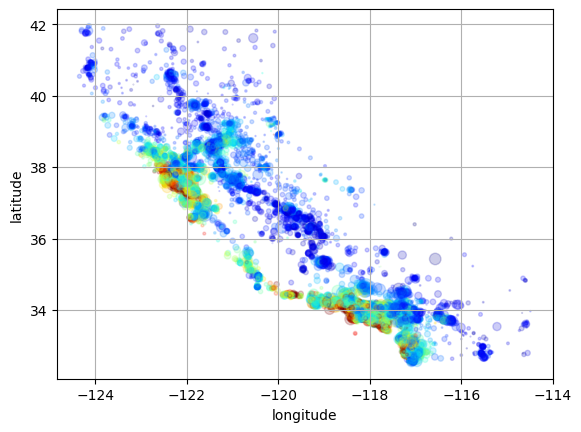

In [16]:
plot1 = plt.scatter(x=housing["longitude"], y=housing["latitude"], s=housing["population"] / 100, c=housing["median_house_value"], cmap="jet")
plot1.set_alpha(0.2)
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.figsize=(10, 7)
plt.grid(True)
plt.show()

Alternative Approach:

In [17]:
# housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
#              s=housing["population"] / 100, label="population",
#              c="median_house_value", cmap="jet", colorbar=True,
#              legend=True, sharex=False, figsize=(10, 7))
# plt.show()

The argument `sharex=False` fixes a display bug: without it, the x-axis values and label are not displayed (see: https://github.com/pandas-dev/pandas/issues/10611).

## Looking for Correlations

In [18]:
corr_matrix = housing.corr()
corr_matrix

<ipython-input-18-35947d78f589>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = housing.corr()


,Unnamed: 0,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
Unnamed: 0,1.000000,-0.002214,0.011732,-0.008999,0.002337,-0.000112,0.003230,0.002439,-0.001128,-0.008913
longitude,-0.002214,1.000000,-0.924213,-0.102937,0.044558,0.068210,0.104236,0.054261,-0.016542,-0.050859
latitude,0.011732,-0.924213,1.000000,0.005692,-0.036753,-0.066391,-0.115677,-0.071604,-0.078137,-0.139584
housing_median_age,-0.008999,-0.102937,0.005692,1.000000,-0.361710,-0.317978,-0.301906,-0.300075,-0.127043,0.102175
total_rooms,0.002337,0.044558,-0.036753,-0.361710,1.000000,0.930076,0.863967,0.916143,0.197720,0.137455
total_bedrooms,-0.000112,0.068210,-0.066391,-0.317978,0.930076,1.000000,0.886200,0.978822,-0.006038,0.054635
population,0.003230,0.104236,-0.115677,-0.301906,0.863967,0.886200,1.000000,0.916237,0.004282,-0.020153
households,0.002439,0.054261,-0.071604,-0.300075,0.916143,0.978822,0.916237,1.000000,0.013637,0.071426
median_income,-0.001128,-0.016542,-0.078137,-0.127043,0.197720,-0.006038,0.004282,0.013637,1.000000,0.688380
median_house_value,-0.008913,-0.050859,-0.139584,0.102175,0.137455,0.054635,-0.020153,0.071426,0.688380,1.000000


median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397

In [19]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
Unnamed: 0           -0.008913
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

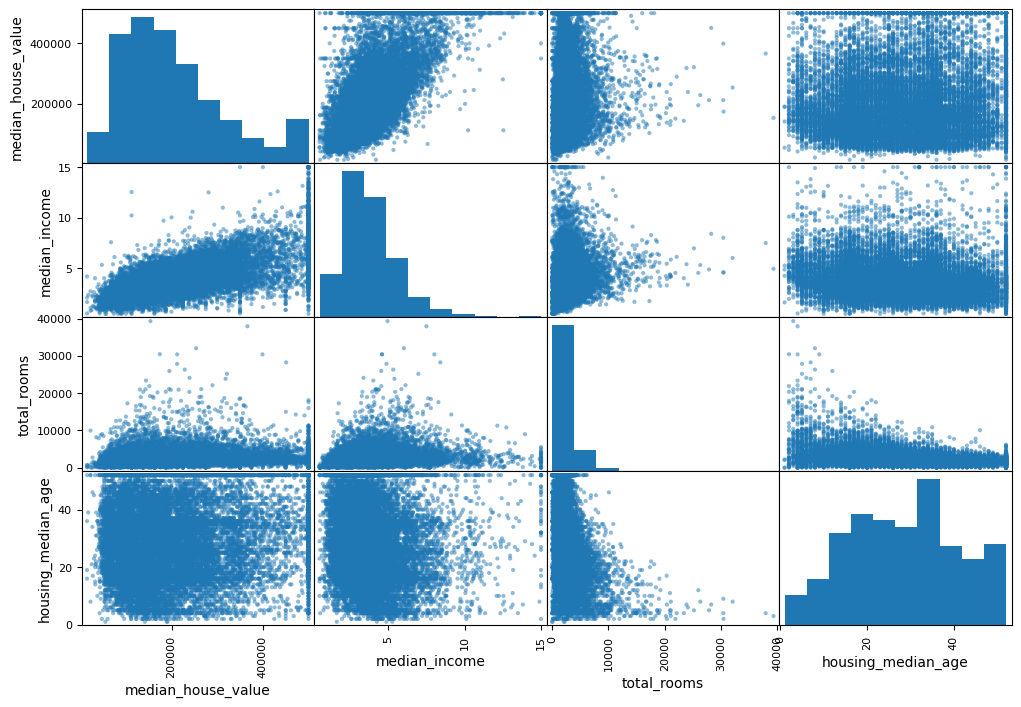

In [20]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

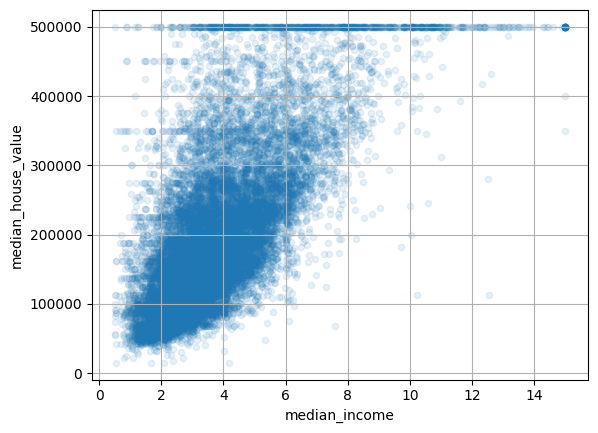

In [21]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",alpha=0.1, grid=True)
plt.show()

## Experimenting with Attribute Combinations

In [22]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [23]:
corr_matrix = housing.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

<ipython-input-23-51a0e6bf2eb4>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = housing.corr()


median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
Unnamed: 0           -0.008913
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

# Prepare the Data for Machine Learning Algorithms

Let's revert to the original training set and separate the target (note that `strat_train_set.drop()` creates a copy of `strat_train_set` without the column, it doesn't actually modify `strat_train_set` itself, unless you pass `inplace=True`):

In [24]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

## Data Cleaning

### Missing Data
Here are 3 options:

```python
housing.dropna(subset=["total_bedrooms"], inplace=True)    # option 1

housing.drop("total_bedrooms", axis=1)       # option 2

median = housing["total_bedrooms"].median()  # option 3
housing["total_bedrooms"].fillna(median, inplace=True)
```

For each option, we'll create a copy of `housing` and work on that copy to avoid breaking `housing`. We'll also show the output of each option, but filtering on the rows that originally contained a NaN value.

In [25]:
null_rows_idx = housing.isnull().any(axis=1)
housing.loc[null_rows_idx].head()

,Unnamed: 0,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,14452,-120.67,40.50,15,5343,NaN,2503,902,3.5962,INLAND
18217,18217,-117.96,34.03,35,2093,NaN,1755,403,3.4115,<1H OCEAN
11889,11889,-118.05,34.04,33,1348,NaN,1098,257,4.2917,<1H OCEAN
20325,20325,-118.88,34.17,15,4260,NaN,1701,669,5.1033,<1H OCEAN
14360,14360,-117.87,33.62,8,1266,NaN,375,183,9.8020,<1H OCEAN


In [26]:
housing_option1 = housing.copy()

housing_option1.dropna(subset=["total_bedrooms"], inplace=True)  # option 1

housing_option1.loc[null_rows_idx].head()

,Unnamed: 0,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


In [27]:
housing_option2 = housing.copy()

housing_option2.drop("total_bedrooms", axis=1, inplace=True)  # option 2

housing_option2.loc[null_rows_idx].head()

,Unnamed: 0,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
14452,14452,-120.67,40.50,15,5343,2503,902,3.5962,INLAND
18217,18217,-117.96,34.03,35,2093,1755,403,3.4115,<1H OCEAN
11889,11889,-118.05,34.04,33,1348,1098,257,4.2917,<1H OCEAN
20325,20325,-118.88,34.17,15,4260,1701,669,5.1033,<1H OCEAN
14360,14360,-117.87,33.62,8,1266,375,183,9.8020,<1H OCEAN


In [28]:
housing_option3 = housing.copy()

median = housing["total_bedrooms"].median()
housing_option3["total_bedrooms"].fillna(median, inplace=True)  # option 3

housing_option3.loc[null_rows_idx].head()

,Unnamed: 0,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,14452,-120.67,40.50,15,5343,434.0,2503,902,3.5962,INLAND
18217,18217,-117.96,34.03,35,2093,434.0,1755,403,3.4115,<1H OCEAN
11889,11889,-118.05,34.04,33,1348,434.0,1098,257,4.2917,<1H OCEAN
20325,20325,-118.88,34.17,15,4260,434.0,1701,669,5.1033,<1H OCEAN
14360,14360,-117.87,33.62,8,1266,434.0,375,183,9.8020,<1H OCEAN


In [29]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

Separating out the numerical attributes to use the `"median"` strategy (as it cannot be calculated on text attributes like `ocean_proximity`):

In [30]:
housing_num = housing.select_dtypes(include=[np.number])

In [31]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [32]:
imputer.statistics_

array([ 1.03465e+04, -1.18510e+02,  3.42600e+01,  2.90000e+01,
        2.12500e+03,  4.34000e+02,  1.16700e+03,  4.08000e+02,
        3.53850e+00])

Check that this is the same as manually computing the median of each attribute:

In [33]:
housing_num.median().values

array([ 1.03465e+04, -1.18510e+02,  3.42600e+01,  2.90000e+01,
        2.12500e+03,  4.34000e+02,  1.16700e+03,  4.08000e+02,
        3.53850e+00])

Transform the training set:

In [34]:
X = imputer.transform(housing_num)


In [35]:
imputer.feature_names_in_

array(['Unnamed: 0', 'longitude', 'latitude', 'housing_median_age',
       'total_rooms', 'total_bedrooms', 'population', 'households',
       'median_income'], dtype=object)

In [36]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,index=housing_num.index)

In [37]:
housing_tr.loc[null_rows_idx].head()

,Unnamed: 0,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,14452.0,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,18217.0,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,11889.0,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,20325.0,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,14360.0,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020


In [38]:
imputer.strategy

'median'

In [39]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

In [40]:
housing_tr.loc[null_rows_idx].head()  # not shown in the book

,Unnamed: 0,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,14452.0,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,18217.0,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,11889.0,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,20325.0,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,14360.0,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020


### Handling Text and Categorical Attributes



<font color = "red">Question</font>
How should we handle categorical data in dataset?

Now let's preprocess the categorical input feature, `ocean_proximity`:

In [41]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


In [42]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [43]:
housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [44]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

<font color = "red">Question</font>
What is the challenge of using OrdinalEncoder?

In [45]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [46]:
housing_cat_1hot

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

<font color = "red">Question</font>
What is the challenge of using OneHotEncoder?

In [47]:
housing_cat_1hot[0].todense()

matrix([[0., 0., 0., 1., 0.]])

In [48]:
housing_cat_1hot[0].toarray()

array([[0., 0., 0., 1., 0.]])

By default, the `OneHotEncoder` class returns a sparse array, but we can convert it to a dense array if needed by calling the `toarray()` method:

In [49]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

Alternatively, you can set `sparse=False` when creating the `OneHotEncoder`:

In [50]:
cat_encoder = OneHotEncoder(sparse=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

In [51]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [52]:
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
pd.get_dummies(df_test)
df_test

,ocean_proximity
0,INLAND
1,NEAR BAY


In [53]:
cat_encoder.transform(df_test)

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [54]:
df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND"]})
pd.get_dummies(df_test_unknown)
df_test_unknown

,ocean_proximity
0,<2H OCEAN
1,ISLAND


In [55]:
cat_encoder.handle_unknown = "ignore"
cat_encoder.transform(df_test_unknown)

array([[0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

In [56]:
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [57]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [58]:
df_output = pd.DataFrame(cat_encoder.transform(df_test_unknown),
                         columns=cat_encoder.get_feature_names_out(),
                         index=df_test_unknown.index)

In [59]:
df_output

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0


### Feature Scaling

*   Normalization (min-max scaler): Normalization often also simply called Min-Max scaling basically shrinks the range of the data such that the range is fixed between 0 and 1 (or -1 to 1 if there are negative values).
Bounds the data within a range.

*   Standardization: Standardization is the process of re-scaling the features so that they’ll have the properties of a Gaussian distribution with mean = 0 and standard deviation of 1.
Gets less affected by outliers.

In [60]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [61]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

### Transformation Pipelines

Now let's build a pipeline to preprocess the numerical attributes:

In [62]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

In [63]:
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

In [64]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[ 0.46, -1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.78,  0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [65]:
from sklearn.compose import ColumnTransformer

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

In [66]:
housing_prepared = full_pipeline.fit_transform(housing)